# Implementing MLP
In this file I train and use an MLP to predict the numerical results of this problem.

In [87]:
# import modules
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [88]:
# load the mass-spring dataset
data = np.loadtxt("mass_spring_data.csv", delimiter=",", skiprows=1)


# Extract columns
t = data[:, 0]
force = data[:, 1]
x = data[:, 2]
v = data[:, 3]


print("Dataset loaded.")
print(f"Number of samples: {len(t)}")
print()

Dataset loaded.
Number of samples: 2000



In [89]:
# Convert NumPy arrays to PyTorch tensors
t_tensor = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)

x_tensor = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)


print("Tensor shapes:")
print(f"t_tensor: {t_tensor.shape}")
print(f"x_tensor: {x_tensor.shape}")
print()

Tensor shapes:
t_tensor: torch.Size([2000, 1])
x_tensor: torch.Size([2000, 1])



In [90]:
# define the neural network
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Input: time
            nn.Linear(1, 32),

            # Nonlinearity
            nn.Tanh(),

            # Hidden layer
            nn.Linear(32, 32),

            # Nonlinearity
            nn.Tanh(),

            # Output: displacement
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.network(t)


In [91]:
# Create the model
model = MLP()

print("Model:")
print(model)
print()

Model:
MLP(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)



In [92]:
# define loss function
loss_function = nn.MSELoss()

In [93]:
# define optimizer
optimizer = torch.optim.Adam(model.parameters())

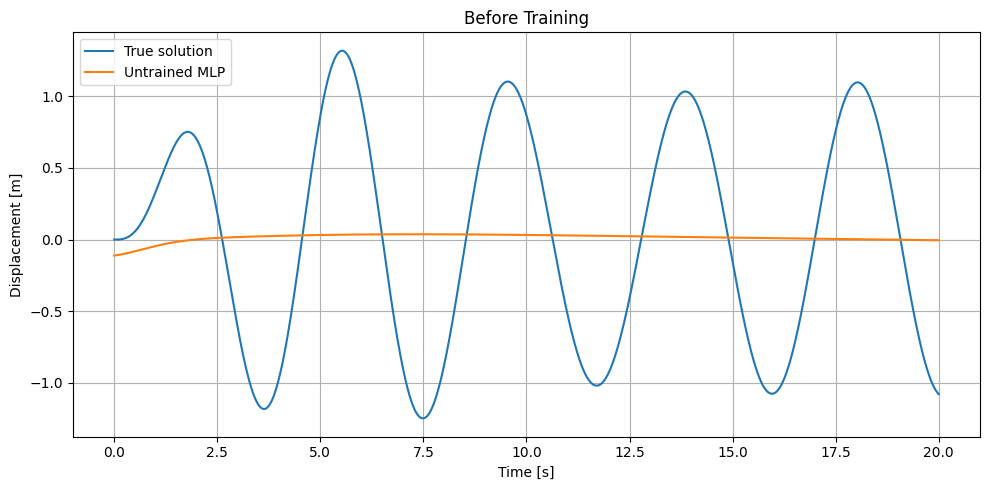

In [94]:
# plot the untrained model
with torch.no_grad():

    initial_prediction = model(t_tensor)


plt.figure(figsize=(10, 5))

plt.plot(t, x, label="True solution")

plt.plot(t, initial_prediction.numpy(), label="Untrained MLP")

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Before Training")

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

In [95]:
# train the model
epochs = 5000

loss_history = []


for epoch in range(epochs):

    # Forward pass
    prediction = model(t_tensor)

    # Calculate loss
    loss = loss_function(prediction, x_tensor)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update network parameters
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Print training progress
    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.item():.8f}"
        )

Epoch     0 | Loss = 0.58427018
Epoch   500 | Loss = 0.50220507
Epoch  1000 | Loss = 0.46162164
Epoch  1500 | Loss = 0.43867671
Epoch  2000 | Loss = 0.42180127
Epoch  2500 | Loss = 0.40712658
Epoch  3000 | Loss = 0.38540024
Epoch  3500 | Loss = 0.35896930
Epoch  4000 | Loss = 0.33925530
Epoch  4500 | Loss = 0.32660323


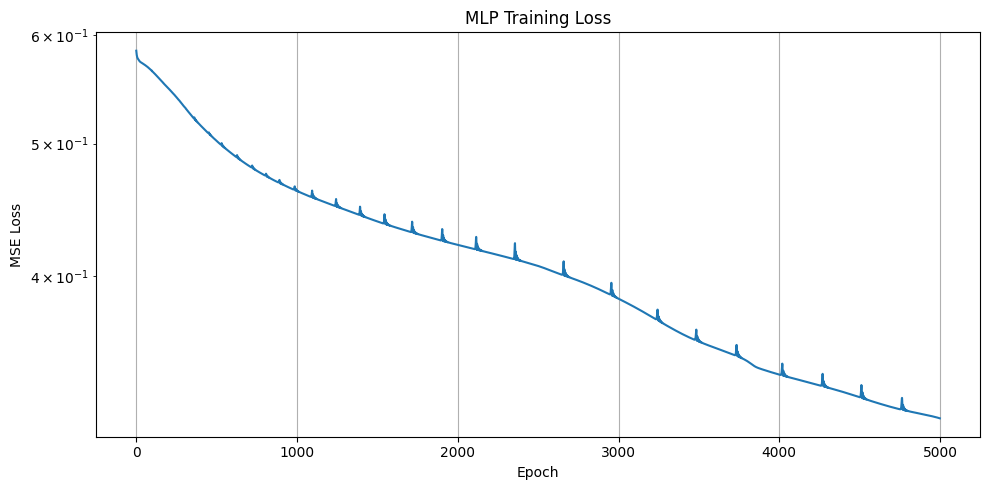

In [96]:
# plot training loss
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training Loss")

# Log scale makes decreasing loss easier to see
plt.yscale("log")

plt.grid()
plt.tight_layout()

plt.show()

In [97]:
# generate final predictions
with torch.no_grad():

    prediction = model(t_tensor)


# Convert PyTorch tensor back to NumPy
prediction = prediction.numpy().flatten()

In [98]:
# calculate error
mse = np.mean((x - prediction) ** 2)

rmse = np.sqrt(mse)


print()
print("==============================")
print("Final Model Performance")
print("==============================")
print(f"MSE  = {mse:.8e}")
print(f"RMSE = {rmse:.8e}")
print()


Final Model Performance
MSE  = 3.15227835e-01
RMSE = 5.61451543e-01



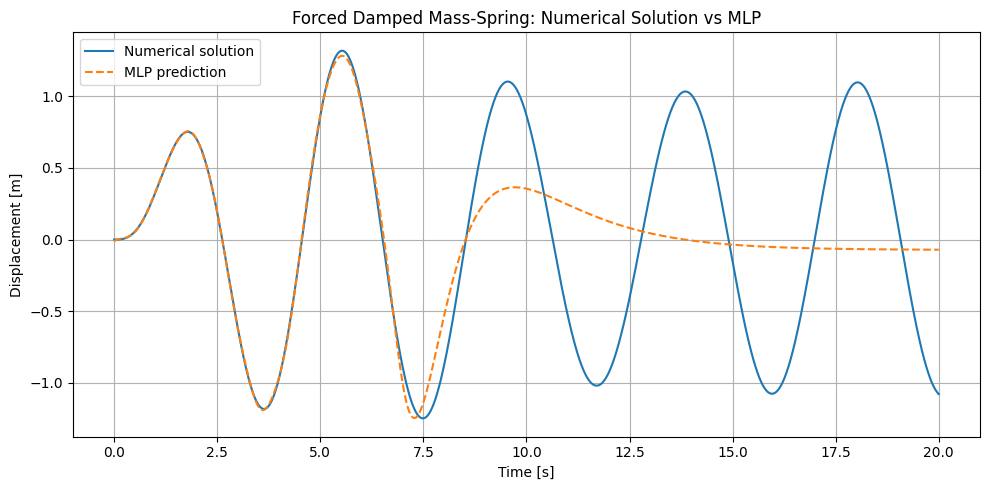

In [99]:
# plot true solution vs MLP
plt.figure(figsize=(10, 5))

plt.plot(
    t,
    x,
    label="Numerical solution"
)

plt.plot(
    t,
    prediction,
    "--",
    label="MLP prediction"
)

plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title(
    "Forced Damped Mass-Spring: "
    "Numerical Solution vs MLP"
)

plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

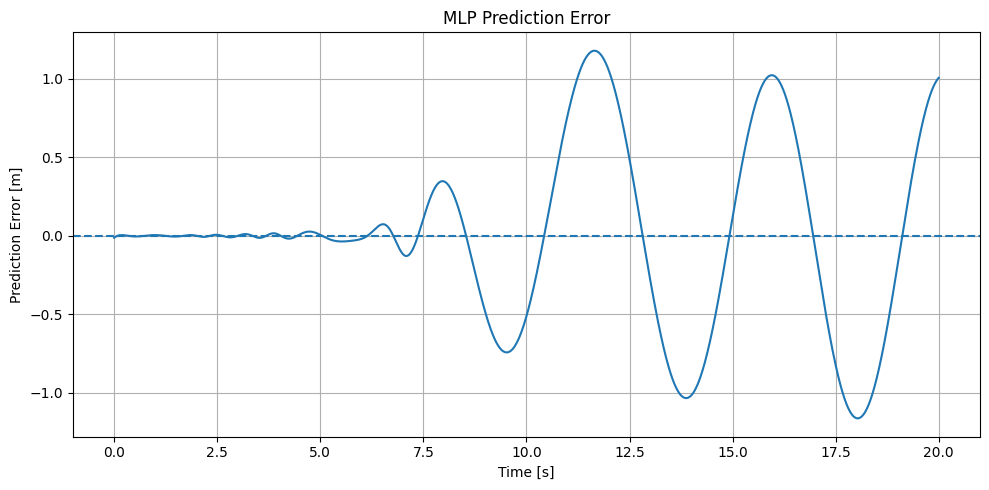

In [100]:
# plot prediction error
error = prediction - x


plt.figure(figsize=(10, 5))

plt.plot(
    t,
    error
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Prediction Error [m]")
plt.title("MLP Prediction Error")

plt.grid()
plt.tight_layout()

plt.show()